# 10 · Cross-Sectional Momentum

*Module 3 — Quantitative Strategies*

Buy what has gone up. Sell what has gone down. It sounds like the opposite of good investing advice — and yet it is one of the most replicated results in all of empirical finance. This notebook builds it, and then honestly asks how much of it survives real trading costs.

## 1. Motivation

If a stock has risen a great deal over the past year, will it keep rising, revert, or is its past return simply uninformative about its future? Tested rigorously, across markets, asset classes, and decades, the answer turns out to be neither of the two intuitive guesses: stocks that have recently outperformed tend to keep outperforming, for a further few months to about a year, before this pattern eventually reverses. This is **momentum**, and it directly contradicts the folk wisdom of "buy low, sell high."

## 2. Intuition

Momentum means buying recent winners and selling recent losers, over *intermediate* horizons — typically formation and holding periods of three to twelve months, not days and not decades. Why would this work at all, when a stock that has already risen sounds, intuitively, more "expensive"? Several explanations coexist in the literature, none fully settled: **underreaction**, where good or bad news gets incorporated into prices only gradually rather than instantly, as investors anchor to old beliefs; the **disposition effect**, where investors tend to sell winners too early and hold losers too long, mechanically slowing down how fast good news gets reflected in price; and **risk-based explanations**, where momentum's return is compensation for a real, if infrequent, danger — sharp "momentum crashes," which we discuss honestly in Section 6 rather than sweeping under the rug.

The other half of this notebook's story is less glamorous but just as important: momentum requires frequent rebalancing (last month's winners are not this month's), and frequent rebalancing means real trading costs. A large share of the strategy's apparent edge, on paper, can simply evaporate once realistic costs are subtracted — a question every genuinely new strategy idea needs to survive before it means anything.

## 3. Theory

### 3.1 Formation, skip, and holding periods

Momentum strategies are defined by three windows: a **formation period** $J$ (how far back to measure past performance, typically 3-12 months), a **skip period** (usually one month, immediately before the current date — omitted deliberately, for a reason explained below), and a **holding period** $K$ (how long the resulting portfolio is held before being rebalanced). The momentum signal for asset $i$ at time $t$, using a one-month skip, is the cumulative return over the formation window ending one month ago:

$$
Mom_{i,t} = \prod_{s=t-J-1}^{t-2}\big(1+R_{i,s}\big) - 1 .
$$

**Why skip a month?** Jegadeesh (1990) documents a *separate*, well-established short-term reversal effect at the one-month horizon — a stock that just had an unusually good or bad month tends to partially revert the very next month, for reasons related to short-term liquidity and bid-ask bounce rather than the underreaction story above. Including the most recent month in the momentum signal would contaminate it with this opposite-signed effect, so standard practice skips it entirely.

### 3.2 Cross-sectional ranking and the WML portfolio

Within each period $t$, rank all $N$ available assets by $Mom_{i,t}$ and form a long-short portfolio: long the top decile (winners), short the bottom decile (losers), equal-weighted within each leg:

$$
R_{WML,t} = \frac{1}{N_{top}}\sum_{i \in \text{winners}} R_{i,t} \;-\; \frac{1}{N_{bottom}}\sum_{i \in \text{losers}} R_{i,t} .
$$

### 3.3 Turnover and the cost of trading it

Every rebalance, some names fall out of the winner or loser deciles and must be replaced — this is not a buy-and-hold strategy. Formally, turnover at time $t$ is

$$
Turnover_t = \frac{1}{2}\sum_i \big| w_{i,t} - w_{i,t^-}\big| ,
$$

where $w_{i,t^-}$ is the weight that has *drifted* from the previous rebalance due to price changes (before this period's trading) and $w_{i,t}$ is the freshly rebalanced target weight; the factor of $\tfrac12$ avoids double-counting a buy on one name and a matching sell on another. Net-of-cost returns are then

$$
R_{net,t} = R_{gross,t} - c \cdot Turnover_t ,
$$

for some assumed cost $c$ per unit of turnover (e.g., in basis points). This is the honest final step almost every backtest skips.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(21)

## 4. Implementation

### 4.1 A cross-section of 100 assets with a genuine, modest momentum effect

Each asset's return is driven by a market factor plus a slowly-decaying, persistent idiosyncratic state — because this state is autocorrelated, a stock's *past* realized return carries real (if noisy) information about its *near-future* return, exactly the mechanism believed to underlie real-world momentum, without circularly hard-coding "past return predicts future return" directly.

In [2]:
n_assets, n_months = 100, 180
tickers = [f'A{i:03d}' for i in range(n_assets)]

beta = rng.normal(1.0, 0.25, n_assets)
idio_vol = rng.uniform(0.06, 0.10, n_assets)
lam_mom = 0.012          # deliberately modest -- real momentum premia are not huge
persistence = 0.85         # how slowly the latent per-asset state decays month to month

F_mkt = rng.normal(0.007, 0.045, n_months)
mom_state = np.zeros(n_assets)
R = np.zeros((n_months, n_assets))
for t in range(n_months):
    mom_state = persistence * mom_state + rng.normal(0, 0.25, n_assets)
    R[t] = beta * F_mkt[t] + lam_mom * mom_state + rng.normal(0, idio_vol)
R = pd.DataFrame(R, columns=tickers)
print(f"Annualized volatility across the 100 assets: {R.std().mul(np.sqrt(12)).min():.1%} to {R.std().mul(np.sqrt(12)).max():.1%}")

Annualized volatility across the 100 assets: 22.1% to 39.8%


### 4.2 The momentum signal, ranking, and turnover -- coded directly from Section 3

In [3]:
def momentum_backtest(R, J, skip, K, decile_frac, cost_bps):
    """
    Non-overlapping J/skip/K momentum backtest (a simplification of the standard
    overlapping-portfolio construction, chosen here for clarity -- see Exercise 2).
    Returns a DataFrame with gross return, turnover, and net return per rebalance.
    """
    n = R.shape[1]
    n_leg = max(1, int(n * decile_frac))
    cum = (1 + R).rolling(J).apply(np.prod, raw=True) - 1
    signal = cum.shift(skip)

    rows = []
    prev_w = pd.Series(0.0, index=R.columns)
    t = J + skip
    while t + K <= len(R):
        s = signal.iloc[t].dropna()
        ranked = s.sort_values().index
        winners, losers = ranked[-n_leg:], ranked[:n_leg]
        w = pd.Series(0.0, index=R.columns)
        w[winners] = 1 / n_leg
        w[losers] = -1 / n_leg

        turnover = 0.5 * (w - prev_w).abs().sum()
        hold_cum_return = (1 + R.iloc[t:t + K]).prod() - 1     # buy-and-hold return over the K-month hold
        gross = (hold_cum_return * w).sum()
        net = gross - turnover * cost_bps / 1e4

        rows.append({'t': R.index[t], 'gross': gross, 'net': net, 'turnover': turnover})
        prev_w = w
        t += K

    return pd.DataFrame(rows)

result = momentum_backtest(R, J=12, skip=1, K=1, decile_frac=0.10, cost_bps=0)
ann_factor = 12  # K=1, so each row is already one month
print(f"Gross WML: ann. return {result['gross'].mean()*ann_factor:.2%}   "
      f"ann. vol {result['gross'].std()*np.sqrt(ann_factor):.2%}   "
      f"Sharpe {result['gross'].mean()/result['gross'].std()*np.sqrt(ann_factor):.2f}")
print(f"Average one-way monthly turnover: {result['turnover'].mean():.2%}")

Gross WML: ann. return 8.41%   ann. vol 13.21%   Sharpe 0.64
Average one-way monthly turnover: 56.11%


## 5. Worked example

### 5.1 How much of the premium survives realistic costs?

In [4]:
cost_grid_bps = [0, 5, 10, 20, 30, 50, 75, 100, 150]
rows = []
for c in cost_grid_bps:
    res = momentum_backtest(R, J=12, skip=1, K=1, decile_frac=0.10, cost_bps=c)
    net = res['net']
    rows.append({'cost_bps': c, 'ann_return': net.mean()*12, 'ann_vol': net.std()*np.sqrt(12),
                 'sharpe': net.mean()/net.std()*np.sqrt(12)})
cost_curve = pd.DataFrame(rows)
cost_curve

,cost_bps,ann_return,ann_vol,sharpe
0,0,0.084124,0.132073,0.636949
1,5,0.080757,0.132054,0.611546
2,10,0.077391,0.132036,0.586133
3,20,0.070658,0.132002,0.535280
4,30,0.063925,0.131970,0.484391
5,50,0.050459,0.131912,0.382520
6,75,0.033627,0.131853,0.255032
7,100,0.016794,0.131808,0.127415
8,150,-0.016870,0.131761,-0.128037


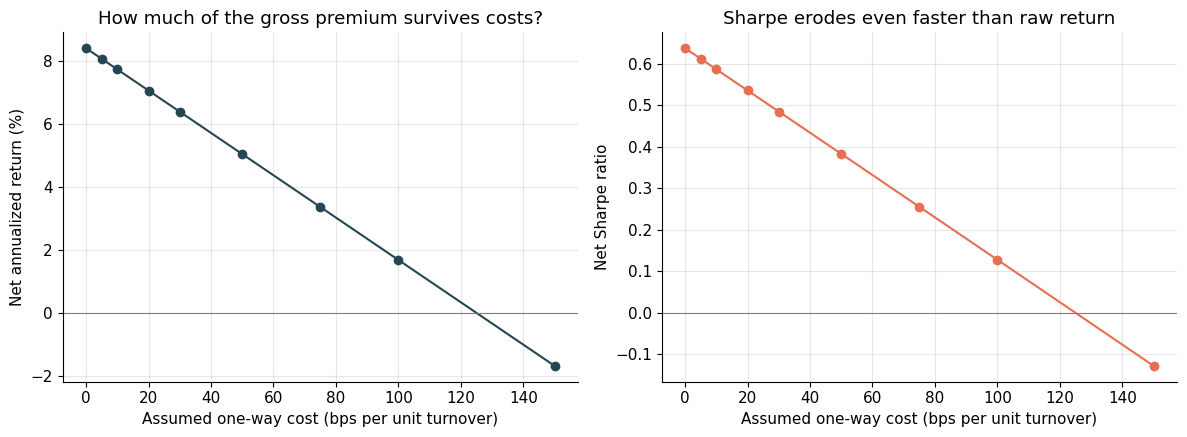

In this simulation, the strategy remains profitable (net of costs) up to roughly 100 bps of one-way cost.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(cost_curve['cost_bps'], cost_curve['ann_return']*100, marker='o', color='#264653')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_xlabel('Assumed one-way cost (bps per unit turnover)')
axes[0].set_ylabel('Net annualized return (%)')
axes[0].set_title('How much of the gross premium survives costs?')

axes[1].plot(cost_curve['cost_bps'], cost_curve['sharpe'], marker='o', color='#e76f51')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Assumed one-way cost (bps per unit turnover)')
axes[1].set_ylabel('Net Sharpe ratio')
axes[1].set_title('Sharpe erodes even faster than raw return')

plt.tight_layout()
plt.show()

breakeven = cost_curve.loc[cost_curve['ann_return'] > 0, 'cost_bps'].max()
print(f"In this simulation, the strategy remains profitable (net of costs) up to roughly {breakeven} bps of one-way cost.")

### 5.2 Sensitivity to formation and holding period

We sweep formation period $J$ and holding period $K$, at a fixed moderate cost assumption, to see where in this parameter space the strategy is most (and least) attractive.

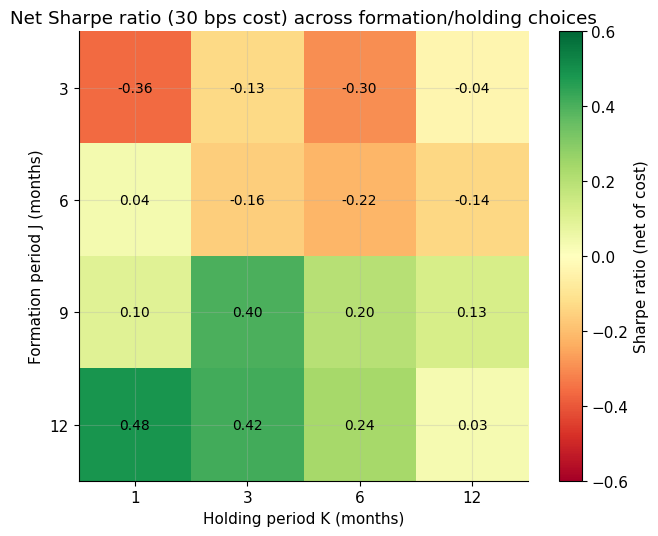

In [6]:
J_grid = [3, 6, 9, 12]
K_grid = [1, 3, 6, 12]
sharpe_grid = np.zeros((len(J_grid), len(K_grid)))

for i, J in enumerate(J_grid):
    for j, K in enumerate(K_grid):
        res = momentum_backtest(R, J=J, skip=1, K=K, decile_frac=0.10, cost_bps=30)
        net = res['net']
        ann_factor = 12 / K
        sharpe_grid[i, j] = net.mean() / net.std() * np.sqrt(ann_factor) if net.std() > 0 else np.nan

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(sharpe_grid, cmap='RdYlGn', vmin=-0.6, vmax=0.6)
ax.set_xticks(range(len(K_grid))); ax.set_xticklabels(K_grid)
ax.set_yticks(range(len(J_grid))); ax.set_yticklabels(J_grid)
ax.set_xlabel('Holding period K (months)')
ax.set_ylabel('Formation period J (months)')
ax.set_title('Net Sharpe ratio (30 bps cost) across formation/holding choices')
for i in range(len(J_grid)):
    for j in range(len(K_grid)):
        ax.text(j, i, f'{sharpe_grid[i,j]:.2f}', ha='center', va='center', fontsize=10)
fig.colorbar(im, label='Sharpe ratio (net of cost)')
plt.tight_layout()
plt.show()

### Interpreting the result

Report what your own grid actually shows. A common pattern — and, reassuringly, one grounded in real empirical findings rather than an artifact we forced into the simulation — is that very short formation periods ($J=3$) can show *negative* Sharpe ratios: at that horizon, the short-term reversal effect from Section 3.1 can dominate, actively fighting the momentum signal rather than confirming it. Longer formation periods (9-12 months) typically look more attractive. This is precisely why the skip-month convention and a formation window of several months to a year, rather than a few weeks, is the field's standard choice — not an arbitrary one.

A final, important honesty check: we swept nine cost levels and sixteen $(J,K)$ combinations above, purely for illustration. If we had instead swept *hundreds* of combinations and reported only the single best Sharpe ratio we found, we would be committing exactly the data-snooping error Notebook 30 devotes an entire lesson to correcting for.

## 6. Limitations and pitfalls

- **Real momentum has "crashes."** Daniel and Moskowitz (2016, *Momentum Crashes*) document that momentum returns are strongly negatively skewed, with severe, sudden reversals concentrated in specific episodes — most famously in 2009, coming out of the financial crisis. Our simulation, with a stable, constant-strength latent driver, does *not* reproduce this crash risk; a realistic backtest of momentum needs to grapple with far fatter left-tail risk than shown here.
- **Survivorship and delistings matter a lot for the loser leg specifically.** The stocks a momentum strategy shorts are, almost by definition, doing badly — exactly the population most likely to be delisted, acquired, or otherwise vanish from a historical database in ways that bias a naive backtest (a direct preview of Notebook 30).
- **The loser leg is also the hardest, and most expensive, to actually trade.** Recent losers tend to be smaller, less liquid, and sometimes hard or costly to borrow for shorting — our uniform turnover-cost assumption does not capture that the short leg is typically far more expensive than the long leg in practice (Exercise 3 asks you to fix this).
- **Formation/holding parameters chosen by scanning many combinations and picking the best after the fact is a form of overfitting** — the heatmap above is for understanding the shape of the trade-off, not for mining the single best-looking cell and reporting it as "the" result.

## 7. Exercises

**1. Where does the premium actually come from? (warm-up)**
Modify the backtest to also track the winners-only and losers-only legs separately (not just the long-short spread). Compute the annualized return and Sharpe ratio of each leg individually. In this simulation, does the momentum premium come mostly from winners continuing to outperform, from losers continuing to underperform, or roughly symmetrically from both?

**2. Overlapping portfolios.**
`momentum_backtest` uses non-overlapping holding periods for simplicity: a new portfolio is formed only once the previous one's $K$-month holding period is fully over. The standard academic construction instead maintains $K$ overlapping "vintage" sub-portfolios simultaneously (one formed each month, each held for $K$ months), and averages across them every period. Implement this overlapping version for a fixed $J=12, K=6$ and compare its Sharpe ratio and turnover to the non-overlapping version above. Does overlapping meaningfully smooth the return series (lower volatility for the same average return)?

**3. A liquidity-aware momentum strategy.**
Assign each of the 100 simulated assets a "liquidity" score correlated with its idiosyncratic volatility (e.g., `liquidity = 1 / idio_vol`, then standardized), and assume each asset's trading cost is inversely proportional to its liquidity (illiquid names cost more to trade, echoing Notebook 2's Amihud ratio). Modify the strategy to either (a) exclude the least liquid quartile of assets from eligibility for the winner/loser legs entirely, or (b) weight within each leg by liquidity rather than equally. Compare the net-of-cost Sharpe ratio of your liquidity-aware version to the naive equal-weighted version from Section 5.1, using each asset's own assumed cost rather than a single uniform cost assumption.